# Preference 데이터 준비

> DPO의 학습 품질은 "chosen과 rejected의 차이가 얼마나 의미 있는가"에 달려 있다

SFT 데이터가 `instruction + output`이었다면, DPO 데이터는 `prompt + chosen + rejected`이다.  
이 노트북에서 UltraFeedback 데이터를 탐색하고 DPOTrainer 형식으로 변환한다.

In [ ]:
# === 환경 설치 ===
!pip install datasets transformers matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("Phase 6-02: Preference 데이터 준비")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phase 6-02: Preference 데이터 준비


---
## 1. Preference 데이터 구조

| 필드 | 역할 | 중요 조건 |
|------|------|----------|
| prompt | 사용자 입력 | 비어있으면 안 됨 |
| chosen | 선호 응답 | rejected보다 객관적으로 나아야 함 |
| rejected | 비선호 응답 | 완전히 틀린 것이 아니라 "덜 좋은" 것 |

In [2]:
# === Preference 데이터 예시 ===

examples = [
    {
        "prompt": "파이썬 정렬 방법은?",
        "chosen": "sorted()는 새 리스트를 반환하고, .sort()는 제자리 정렬합니다.\n"
                  "예시: sorted([3,1,2]) → [1,2,3]\n"
                  "key 파라미터로 정렬 기준을 커스텀할 수 있습니다.",
        "rejected": "sort 쓰면 됩니다."
    },
    {
        "prompt": "딥러닝과 머신러닝의 차이는?",
        "chosen": "머신러닝은 데이터에서 패턴을 학습하는 AI의 하위 분야이고, "
                  "딥러닝은 다층 신경망을 사용하는 머신러닝의 하위 분야입니다. "
                  "딥러닝은 특히 이미지, 자연어 처리에서 뛰어난 성능을 보입니다.",
        "rejected": "딥러닝이 더 좋습니다. 머신러닝은 구식입니다."
    },
]

for i, ex in enumerate(examples):
    print(f"예시 {i+1}:")
    print(f"  prompt:   {ex['prompt']}")
    print(f"  chosen:   {ex['chosen'][:80]}...")
    print(f"  rejected: {ex['rejected'][:80]}")
    print(f"  차이: chosen이 구체적이고 예시 포함 vs rejected가 피상적")
    print()

예시 1:
  prompt:   파이썬 정렬 방법은?
  chosen:   sorted()는 새 리스트를 반환하고, .sort()는 제자리 정렬합니다.
예시: sorted([3,1,2]) → [1,2,3]
key 파라미...
  rejected: sort 쓰면 됩니다.
  차이: chosen이 구체적이고 예시 포함 vs rejected가 피상적

예시 2:
  prompt:   딥러닝과 머신러닝의 차이는?
  chosen:   머신러닝은 데이터에서 패턴을 학습하는 AI의 하위 분야이고, 딥러닝은 다층 신경망을 사용하는 머신러닝의 하위 분야입니다. 딥러닝은 특히 이미지,...
  rejected: 딥러닝이 더 좋습니다. 머신러닝은 구식입니다.
  차이: chosen이 구체적이고 예시 포함 vs rejected가 피상적



---
## 2. UltraFeedback 데이터셋 탐색

GPT-4가 여러 모델의 응답에 점수를 매겨  
높은 점수 = chosen, 낮은 점수 = rejected로 구성.  
**가장 널리 사용**되는 범용 preference 데이터셋.

In [3]:
# === UltraFeedback 로드 ===

dataset = load_dataset("HuggingFaceH4/ultrafeedback_binarized", split="train_prefs")

print(f"UltraFeedback 전체: {len(dataset)}개")
print(f"컬럼: {dataset.column_names}")
print(f"\n첫 번째 샘플 키: {list(dataset[0].keys())}")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jskim\.cache\huggingface\hub\datasets--HuggingFaceH4--ultrafeedback_binarized. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test_gen split: 100%|██████████| 1000/1000 [00:00<00:00, 37145.02 examples/

UltraFeedback 전체: 61135개
컬럼: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']

첫 번째 샘플 키: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']


In [4]:
# === 데이터 구조 탐색 ===

sample = dataset[0]
print("샘플 구조:")
print(f"  prompt: {str(sample.get('prompt', ''))[:100]}")

# chosen/rejected 구조 확인
if 'chosen' in sample:
    chosen = sample['chosen']
    if isinstance(chosen, list):
        print(f"  chosen: list of {len(chosen)} messages")
        for msg in chosen[:2]:
            print(f"    role: {msg.get('role', '?')}, content: {str(msg.get('content', ''))[:60]}...")
    else:
        print(f"  chosen: {str(chosen)[:100]}")

if 'rejected' in sample:
    rejected = sample['rejected']
    if isinstance(rejected, list):
        print(f"  rejected: list of {len(rejected)} messages")
        for msg in rejected[:2]:
            print(f"    role: {msg.get('role', '?')}, content: {str(msg.get('content', ''))[:60]}...")
    else:
        print(f"  rejected: {str(rejected)[:100]}")

# score 정보
for key in ['score_chosen', 'score_rejected', 'chosen_rating', 'rejected_rating']:
    if key in sample:
        print(f"  {key}: {sample[key]}")

샘플 구조:
  prompt: how can i develop a habit of drawing daily
  chosen: list of 2 messages
    role: user, content: how can i develop a habit of drawing daily...
    role: assistant, content: Developing a daily habit of drawing can be challenging but w...
  rejected: list of 2 messages
    role: user, content: how can i develop a habit of drawing daily...
    role: assistant, content: As an AI language model, I cannot personally develop habits ...
  score_chosen: 8.5
  score_rejected: 8.5


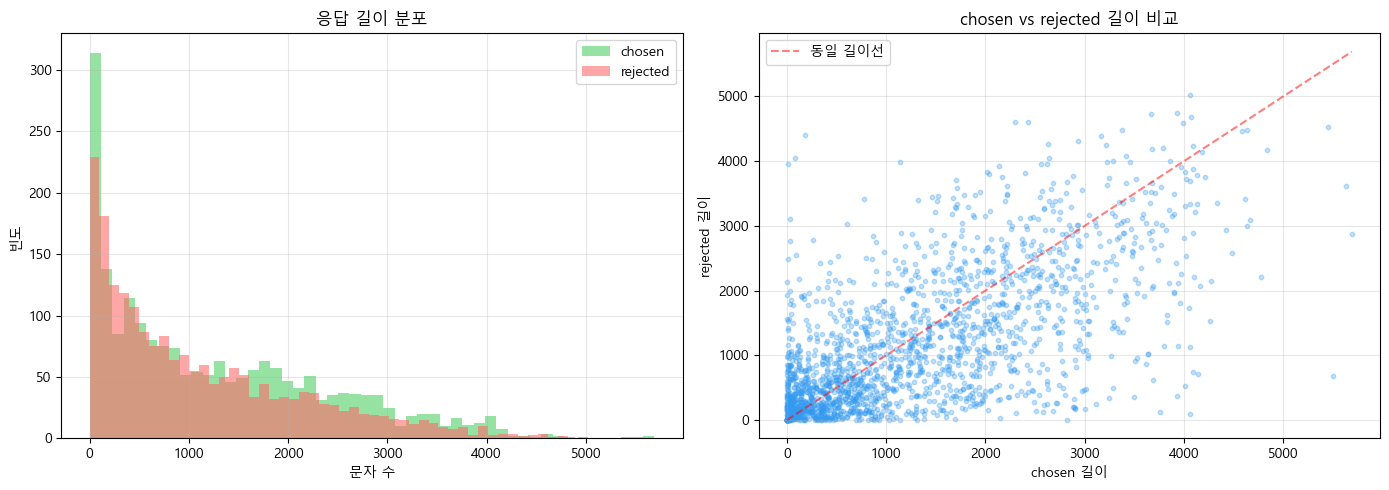


chosen 길이:   평균 1273, 중앙값 970
rejected 길이: 평균 1122, 중앙값 794

→ chosen이 보통 더 길다 (더 상세한 응답)


In [5]:
# === 길이 분포 분석 ===

# 서브셋으로 분석 (속도)
analysis_data = dataset.select(range(min(2000, len(dataset))))

def get_text_length(sample):
    """chosen/rejected에서 텍스트 길이 추출"""
    chosen = sample.get('chosen', '')
    rejected = sample.get('rejected', '')
    
    if isinstance(chosen, list):
        chosen_text = ' '.join(m.get('content', '') for m in chosen if m.get('role') == 'assistant')
        rejected_text = ' '.join(m.get('content', '') for m in rejected if m.get('role') == 'assistant')
    else:
        chosen_text = str(chosen)
        rejected_text = str(rejected)
    
    return len(chosen_text), len(rejected_text)

chosen_lengths = []
rejected_lengths = []
for sample in analysis_data:
    cl, rl = get_text_length(sample)
    chosen_lengths.append(cl)
    rejected_lengths.append(rl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 길이 분포 히스토그램
axes[0].hist(chosen_lengths, bins=50, alpha=0.6, label='chosen', color='#51cf66')
axes[0].hist(rejected_lengths, bins=50, alpha=0.6, label='rejected', color='#ff6b6b')
axes[0].set_xlabel('문자 수')
axes[0].set_ylabel('빈도')
axes[0].set_title('응답 길이 분포')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) chosen vs rejected 길이 산점도
axes[1].scatter(chosen_lengths, rejected_lengths, alpha=0.3, s=10, color='#339af0')
max_len = max(max(chosen_lengths), max(rejected_lengths))
axes[1].plot([0, max_len], [0, max_len], 'r--', alpha=0.5, label='동일 길이선')
axes[1].set_xlabel('chosen 길이')
axes[1].set_ylabel('rejected 길이')
axes[1].set_title('chosen vs rejected 길이 비교')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nchosen 길이:   평균 {np.mean(chosen_lengths):.0f}, 중앙값 {np.median(chosen_lengths):.0f}")
print(f"rejected 길이: 평균 {np.mean(rejected_lengths):.0f}, 중앙값 {np.median(rejected_lengths):.0f}")
print(f"\n→ chosen이 보통 더 길다 (더 상세한 응답)")

---
## 3. DPOTrainer 형식 변환

TRL의 DPOTrainer가 기대하는 형식:
- `prompt`: 사용자 질문 (문자열 또는 메시지 리스트)
- `chosen`: 선호 응답 (문자열 또는 메시지 리스트)
- `rejected`: 비선호 응답 (문자열 또는 메시지 리스트)

In [6]:
# === DPOTrainer 형식 변환 ===

def format_for_dpo(sample):
    """
    UltraFeedback 데이터를 DPOTrainer 형식으로 변환.
    TRL v0.28+에서는 메시지 리스트 형식도 지원한다.
    """
    prompt = sample.get('prompt', '')
    chosen = sample.get('chosen', [])
    rejected = sample.get('rejected', [])
    
    # 메시지 리스트 형식인 경우
    if isinstance(chosen, list) and len(chosen) > 0:
        # prompt 추출 (user 메시지)
        prompt_msgs = [m for m in chosen if m.get('role') == 'user']
        if prompt_msgs:
            prompt = prompt_msgs[0].get('content', prompt)
        
        # assistant 응답 추출
        chosen_msgs = [m for m in chosen if m.get('role') == 'assistant']
        rejected_msgs = [m for m in rejected if m.get('role') == 'assistant']
        
        chosen_text = chosen_msgs[0].get('content', '') if chosen_msgs else ''
        rejected_text = rejected_msgs[0].get('content', '') if rejected_msgs else ''
    else:
        chosen_text = str(chosen)
        rejected_text = str(rejected)
    
    return {
        "prompt": prompt,
        "chosen": chosen_text,
        "rejected": rejected_text,
    }

# 변환 실행 (1000개 서브셋)
subset = dataset.select(range(1000))
dpo_data = subset.map(format_for_dpo, remove_columns=subset.column_names)

# 빈 데이터 필터링
dpo_data = dpo_data.filter(lambda x: len(x['prompt'].strip()) > 0 
                           and len(x['chosen'].strip()) > 0 
                           and len(x['rejected'].strip()) > 0)

print(f"변환 완료: {len(dpo_data)}개")
print(f"컬럼: {dpo_data.column_names}")
print(f"\n변환된 샘플:")
for i in range(3):
    s = dpo_data[i]
    print(f"\n[{i}] prompt:   {s['prompt'][:80]}...")
    print(f"    chosen:   {s['chosen'][:80]}...")
    print(f"    rejected: {s['rejected'][:80]}...")

Filter: 100%|██████████| 1000/1000 [00:00<00:00, 36994.64 examples/s]

변환 완료: 1000개
컬럼: ['prompt', 'chosen', 'rejected']

변환된 샘플:

[0] prompt:   how can i develop a habit of drawing daily...
    chosen:   Developing a daily habit of drawing can be challenging but with consistent pract...
    rejected: As an AI language model, I cannot personally develop habits for you. But, here a...

[1] prompt:   how can I transform the getPosition method of antv/g's group in zrender?...
    chosen:   It is not recommended to modify built-in methods as it can lead to unexpected re...
    rejected: Thank you for reaching out for assistance! I'm here to help you with your questi...

[2] prompt:   Given a sentence in French, provide an equivalent paraphrased version from the o...
    chosen:   Crockett a déménagé de Natchez (Mississippi) à Vidalia, siège de la paroisse de ...
    rejected: Sure! I'd be happy to help with your questions. Here are the paraphrased version...


In [7]:
# === Train / Validation 분할 ===

split = dpo_data.train_test_split(test_size=0.1, seed=42)
train_pref = split['train']
val_pref = split['test']

print(f"DPO Train: {len(train_pref)}개")
print(f"DPO Val:   {len(val_pref)}개")

# 저장 (다음 노트북에서 사용)
train_pref.save_to_disk("./output/dpo_data_train")
val_pref.save_to_disk("./output/dpo_data_val")
print("\n저장 완료: ./output/dpo_data_train, ./output/dpo_data_val")

DPO Train: 900개
DPO Val:   100개


Saving the dataset (1/1 shards): 100%|██████████| 100/100 [00:00<00:00, 16557.99 examples/s]


저장 완료: ./output/dpo_data_train, ./output/dpo_data_val


---
## 4. 커스텀 Preference 데이터

실전에서는 **자신의 도메인에 맞는 preference 데이터를 직접 만들어야** 한다.  
여기서는 SQL 도메인 예시를 보여준다.

In [8]:
# === SQL 도메인 커스텀 Preference ===

sql_preferences = [
    {
        "prompt": "사용자별 총 주문 금액을 구하는 SQL을 작성해줘",
        "chosen": "SELECT u.user_id, u.name, SUM(o.amount) as total_amount\n"
                  "FROM users u\n"
                  "JOIN orders o ON u.user_id = o.user_id\n"
                  "GROUP BY u.user_id, u.name\n"
                  "ORDER BY total_amount DESC;",
        "rejected": "SELECT * FROM orders GROUP BY user_id;"
    },
    {
        "prompt": "최근 30일 내 주문이 없는 고객을 찾는 SQL을 작성해줘",
        "chosen": "SELECT u.user_id, u.name, u.email\n"
                  "FROM users u\n"
                  "WHERE u.user_id NOT IN (\n"
                  "    SELECT DISTINCT user_id FROM orders\n"
                  "    WHERE order_date >= DATE_SUB(CURDATE(), INTERVAL 30 DAY)\n"
                  ");",
        "rejected": "SELECT * FROM users WHERE order_date < 30;"
    },
    {
        "prompt": "상품 카테고리별 평균 가격을 구해줘",
        "chosen": "SELECT c.category_name, \n"
                  "       ROUND(AVG(p.price), 2) as avg_price,\n"
                  "       COUNT(p.product_id) as product_count\n"
                  "FROM categories c\n"
                  "JOIN products p ON c.category_id = p.category_id\n"
                  "GROUP BY c.category_name\n"
                  "ORDER BY avg_price DESC;",
        "rejected": "SELECT AVG(price) FROM products;"
    },
]

sql_pref_dataset = Dataset.from_list(sql_preferences)

print("SQL 커스텀 Preference 데이터:")
for i, ex in enumerate(sql_preferences):
    print(f"\n[{i}] prompt: {ex['prompt']}")
    print(f"  chosen:   정확한 JOIN, GROUP BY, ORDER BY 포함")
    print(f"  rejected: 문법 오류 또는 불완전")

print(f"\n총 {len(sql_pref_dataset)}개 (실전에서는 100~1000개 필요)")

SQL 커스텀 Preference 데이터:

[0] prompt: 사용자별 총 주문 금액을 구하는 SQL을 작성해줘
  chosen:   정확한 JOIN, GROUP BY, ORDER BY 포함
  rejected: 문법 오류 또는 불완전

[1] prompt: 최근 30일 내 주문이 없는 고객을 찾는 SQL을 작성해줘
  chosen:   정확한 JOIN, GROUP BY, ORDER BY 포함
  rejected: 문법 오류 또는 불완전

[2] prompt: 상품 카테고리별 평균 가격을 구해줘
  chosen:   정확한 JOIN, GROUP BY, ORDER BY 포함
  rejected: 문법 오류 또는 불완전

총 3개 (실전에서는 100~1000개 필요)


---
## 5. 데이터 품질 검증

| 좋은 preference 쌍 | 나쁜 preference 쌍 |
|-------------------|-------------------|
| chosen이 구체적, rejected가 피상적 | 둘 다 비슷한 품질 |
| 차이가 명확하고 학습 가능 | chosen == rejected (동일) |
| 도메인에 맞는 판단 기준 | 랜덤 라벨링 |

In [9]:
# === Preference 데이터 품질 검증 함수 ===

def validate_preference_data(dataset, sample_size=100):
    """
    Preference 데이터의 품질을 검증한다.
    """
    print("Preference 데이터 품질 검증")
    print("=" * 50)
    
    issues = []
    n = min(sample_size, len(dataset))
    
    identical_count = 0
    empty_count = 0
    short_chosen = 0
    length_ratios = []
    
    for i in range(n):
        sample = dataset[i]
        prompt = sample.get('prompt', '')
        chosen = sample.get('chosen', '')
        rejected = sample.get('rejected', '')
        
        # 빈 필드 체크
        if not prompt.strip() or not chosen.strip() or not rejected.strip():
            empty_count += 1
        
        # 동일 응답 체크
        if chosen.strip() == rejected.strip():
            identical_count += 1
        
        # chosen이 rejected보다 짧은 경우
        if len(chosen) < len(rejected) * 0.5:
            short_chosen += 1
        
        # 길이 비율
        if len(rejected) > 0:
            length_ratios.append(len(chosen) / len(rejected))
    
    # 결과 출력
    print(f"  검사 샘플: {n}개")
    print(f"  {'✓' if empty_count == 0 else '✗'} 빈 필드: {empty_count}개")
    print(f"  {'✓' if identical_count == 0 else '✗'} 동일 응답: {identical_count}개")
    print(f"  {'✓' if short_chosen < n*0.1 else '△'} chosen < rejected*0.5: {short_chosen}개")
    
    if length_ratios:
        avg_ratio = np.mean(length_ratios)
        print(f"  chosen/rejected 길이 비율: 평균 {avg_ratio:.2f}")
        if avg_ratio < 0.8:
            print(f"    △ chosen이 rejected보다 짧은 경향 (품질 확인 필요)")
    
    if empty_count > 0:
        issues.append(f"빈 필드 {empty_count}개")
    if identical_count > 0:
        issues.append(f"동일 응답 {identical_count}개")
    
    print("\n" + "=" * 50)
    if issues:
        print(f"발견된 문제: {issues}")
    else:
        print("품질 검증 통과!")
    
    return issues

# 검증 실행
validate_preference_data(dpo_data)

Preference 데이터 품질 검증
  검사 샘플: 100개
  ✓ 빈 필드: 0개
  ✓ 동일 응답: 0개
  △ chosen < rejected*0.5: 21개
  chosen/rejected 길이 비율: 평균 2.93

품질 검증 통과!


[]

---
## 정리

| 단계 | 내용 |
|------|------|
| **구조** | prompt + chosen + rejected |
| **데이터셋** | UltraFeedback (60K, GPT-4 점수 기반) |
| **변환** | `format_for_dpo()` → DPOTrainer 형식 |
| **커스텀** | 도메인에 맞는 preference 직접 구축 |
| **검증** | `validate_preference_data()` |

### 핵심 원칙

> **Preference 데이터는 "정답"을 모으는 것이 아니라 "비교"를 모으는 것이다.**  
> chosen과 rejected의 차이가 클수록, 모델이 배우는 판단력도 명확해진다.

### 다음: 03_DPO_파인튜닝_실습.ipynb

준비된 Preference 데이터로 실제 DPO 학습을 실행한다.